Niyati Parekh 
Practicum Project *ShabDub*

In [9]:
#load libraries 
import numpy as np
import pandas as pd
import regex
from datasets import load_dataset
import random
import time
import os
from datetime import datetime
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
import joblib 
import matplotlib.pyplot as plt
import seaborn as sns
import tkinter as tk
from tkinter import ttk

#from urduhack.normalization import normalize
from typing import List

In [19]:
pip install regex

In [13]:
#load the datasets 

hindi_words = pd.read_csv(r"C:\Users\parni\OneDrive\Desktop\DSSA\hindi_vocab.txt")

In [15]:
gujju_words = pd.read_parquet("hf://datasets/Vedant3907/Gujarati-Words-POS-Tags/data/train-00000-of-00001.parquet")

gujju_words = pd.read_csv(r"C:\Users\parni\OneDrive\Desktop\DSSA\gujarati_words.xls")

In [19]:
english_words = pd.read_csv(r"C:\Users\parni\OneDrive\Desktop\DSSA\unigram_freq.csv")

In [16]:
#save the gujju_words to csv locally to use dataset without issues
gujju_words.to_csv("gujarati_words.csv", index=False)

In [546]:
#use this to view any datasets and explore
#hindi_words.columns

english_words.columns

gujju_words.columns

Index(['Gujarati_Tokens'], dtype='object')

In [564]:
gujju_words[:5]

,Gujarati_Tokens
0,તેથી
1,આપણું
2,ખાણ
3,આપણો
4,હવે


In [21]:
# Load words lists from the hindi file 
def load_words(hindi_words):
    #remove whitespace and return a list of words
    with open('hindi_vocab.txt', 'r', encoding='utf-8') as f:
        return [line.strip() for line in f if line.strip()]

#load the list
hindi_words = load_words('hindi_words.txt')
#print the list 
hindi_words

['वार्ष्णेय',
 'फॉर्म्युला',
 'ऊर्ध्वगामी',
 'ऊर्ध्वगमन',
 'पैक्ड',
 'लिंक्ड',
 'गुरुर्ब्रह्मा',
 'याज्ञवल्क्य',
 'अंतर्ध्यान',
 'अर्ध्य',
 'र्ध्म',
 'अर्द्ववृत्त',
 'सौहार्द्रपूर्ण',
 'आर्द्रता',
 'सौहार्द्र',
 'अर्द्धसैनिक',
 'पूर्वार्द्ध',
 'संवर्द्धन',
 'उत्तरार्द्ध',
 'अर्द्ध',
 'सामर्थ्यवान',
 'सामर्थ्य',
 'भर्त्सना',
 'कार्यकर्त्री',
 'सार्त्र',
 'मर्त्यलोक',
 'मर्त्य',
 'अमर्त्य',
 'वर्ण्य',
 'वर्ज्य',
 'फार्च्यून',
 'अमूर्च्छा',
 'मूर्च्छा',
 'अर्घ्य',
 'मार्ग्रेट',
 'फर्ग्युसन',
 'वैशिष्ट्य',
 'एम्ब्युलेन्स',
 'केप्स्यूल',
 'सन्स्मरण',
 'विन्ध्यवासिनी',
 'बन्ध्यीकरण',
 'विन्ध्याचल',
 'सन्ध्या',
 'विन्ध्य',
 'अनिन्द्य',
 'सान्त्वना',
 'स्वातन्त्र्य',
 'अगस्त्यमुनि',
 'पुलस्त्य',
 'अगस्त्य',
 'अस्त्वि',
 'वास्त्विक',
 'दुस्स्वप्न',
 'निस्स्वार्थ',
 'इन्क्लूसिव',
 'कॉन्क्लेव',
 'एन्क्लेव',
 'एन्क्रिप्टेड',
 'इन्क्रीमेंट',
 'एन्क्रिप्शन',
 'इन्कम',
 'इन्कलाब',
 'इन्कार',
 'सद्व्यवहार',
 'दारिद्र्य',
 'एतद्द्वारा',
 'माद्ध्यम',
 'विद्द्या',
 'गद्द्य',
 'उद्द्येश्य',
 'उद्ग्रहण',
 

In [23]:
# Load words lists from the english file 
def load_words(english_words):
    #remove whitespace and return a list of words
    with open('unigram_freq.csv', 'r', encoding='utf-8') as f:
        return [line.strip() for line in f if line.strip()]

#load the list
english_words = load_words('unigram_freq.csv')
#print the list 
english_words

['word,count',
 'the,23135851162',
 'of,13151942776',
 'and,12997637966',
 'to,12136980858',
 'a,9081174698',
 'in,8469404971',
 'for,5933321709',
 'is,4705743816',
 'on,3750423199',
 'that,3400031103',
 'by,3350048871',
 'this,3228469771',
 'with,3183110675',
 'i,3086225277',
 'you,2996181025',
 'it,2813163874',
 'not,2633487141',
 'or,2590739907',
 'be,2398724162',
 'are,2393614870',
 'from,2275595356',
 'at,2272272772',
 'as,2247431740',
 'your,2062066547',
 'all,2022459848',
 'have,1564202750',
 'new,1551258643',
 'more,1544771673',
 'an,1518266684',
 'was,1483428678',
 'we,1390661912',
 'will,1356293641',
 'home,1276852170',
 'can,1242323499',
 'us,1229112622',
 'about,1226734006',
 'if,1134987907',
 'page,1082121730',
 'my,1059793441',
 'has,1046319984',
 'search,1024093118',
 'free,1014107316',
 'but,999899654',
 'our,998757982',
 'one,993536631',
 'other,978481319',
 'do,950751722',
 'no,937112320',
 'information,932594387',
 'time,908705570',
 'they,883223816',
 'site,84431024

In [25]:
# Load words lists from the gujju file 
def load_words(gujarati_words):
    #remove whitespace and return a list of words
    with open('gujarati_words.csv', 'r', encoding='utf-8') as f:
        return [line.strip() for line in f if line.strip()]

#load the list
gujju_words = load_words('gujarati_words.csv')
#print the list 
gujju_words

['Gujarati_Tokens',
 'તેથી',
 'આપણું',
 'ખાણ',
 'આપણો',
 'હવે',
 'અંદર',
 'તમે',
 'અને તેથી વધુ',
 'માં',
 'તેમના',
 'આ',
 'આ',
 'આ',
 'આ',
 'તેના',
 'તેના',
 'તેના',
 'આ માં',
 'એ જ',
 'તેને',
 'તે',
 'તેમના',
 'તેમના',
 'તેમના',
 'તેમને',
 'એ',
 'તેમને',
 'તેમને',
 'તે',
 'તેના',
 'એ જ',
 'તેને',
 'એક',
 'અને',
 'આવા',
 'અને',
 'ઘણા',
 'કર',
 'કરે છે',
 'કરવું',
 'કરવું',
 'શું કરવું',
 'કરો',
 'કહો',
 'કહ્યું',
 'ના',
 'પૂરતૂ',
 'તે',
 'કેટલુ',
 'જે',
 'જે',
 'કર્યું',
 'પાત્ર',
 'ચુંબન',
 'કોઈપણ',
 'ના',
 'કેટલાક',
 'કુલ',
 'ના',
 'પ્રતિ',
 'કોઈ',
 'જે એક',
 'ગયો',
 'ઘર',
 'ક્યારે',
 'જ્યાં',
 'જાઓ',
 'શક્ય હોય તેટલું વધારે',
 'જીન',
 'જેમને',
 'જેમને',
 'જીસ',
 'જેમને',
 'જ્યાં',
 'જેમ',
 'ગમે છે',
 'કે',
 'સુધી',
 'પછી',
 'દયાળુ',
 'ત્રણ',
 'ત્રણ',
 'તેર',
 'ત્રણ',
 'ત્રણ',
 'તેથી',
 'હતી',
 'હતી',
 'હતા',
 'ડબારા',
 'આપ્યો',
 'બીજો',
 'અન્ય',
 'બે',
 'દ્વારા',
 'નથી',
 'નુકે',
 'ના',
 'ના',
 'મોટા પ્રમાણમાં',
 'નીચે',
 'છે',
 'ચાલુ',
 'પ્રથમ',
 'સંપૂર્ણ',
 'પર',
 'ફરી',
 'બનાવેલ

In [29]:
#define a function to split words into graphemes (visible characters)
#mainly needed for gujarati and hindi but here for consistency  
def split_graphemes(word):
    return regex.findall(r'\X', word)

In [31]:
#grapheme splitting to each word in the list
#hindi and gujarati words are unlike english where with separate vowels and consonants
#there are matras(vowel like mark) with the letter so they need to be split accordingly 
gujju_words_split = [split_graphemes(word) for word in gujju_words]

In [33]:
hindi_words_split = [split_graphemes(word) for word in hindi_words]

In [35]:
#verify the grapheme is splitting words appropriate 
for i, word in enumerate(gujju_words):
    print(f"Original: {word} --> Split: {gujju_words_split[i]}")

Original: Gujarati_Tokens --> Split: ['G', 'u', 'j', 'a', 'r', 'a', 't', 'i', '_', 'T', 'o', 'k', 'e', 'n', 's']
Original: તેથી --> Split: ['તે', 'થી']
Original: આપણું --> Split: ['આ', 'પ', 'ણું']
Original: ખાણ --> Split: ['ખા', 'ણ']
Original: આપણો --> Split: ['આ', 'પ', 'ણો']
Original: હવે --> Split: ['હ', 'વે']
Original: અંદર --> Split: ['અં', 'દ', 'ર']
Original: તમે --> Split: ['ત', 'મે']
Original: અને તેથી વધુ --> Split: ['અ', 'ને', ' ', 'તે', 'થી', ' ', 'વ', 'ધુ']
Original: માં --> Split: ['માં']
Original: તેમના --> Split: ['તે', 'મ', 'ના']
Original: આ --> Split: ['આ']
Original: આ --> Split: ['આ']
Original: આ --> Split: ['આ']
Original: આ --> Split: ['આ']
Original: તેના --> Split: ['તે', 'ના']
Original: તેના --> Split: ['તે', 'ના']
Original: તેના --> Split: ['તે', 'ના']
Original: આ માં --> Split: ['આ', ' ', 'માં']
Original: એ જ --> Split: ['એ', ' ', 'જ']
Original: તેને --> Split: ['તે', 'ને']
Original: તે --> Split: ['તે']
Original: તેમના --> Split: ['તે', 'મ', 'ના']
Original: તેમના

In [37]:
#verify the grapheme is splitting words appropriately for hindi
for i, word in enumerate(hindi_words):
    print(f"Original: {word} --> Split: {hindi_words_split[i]}")


Original: वार्ष्णेय --> Split: ['वा', 'र्ष्णे', 'य']
Original: फॉर्म्युला --> Split: ['फॉ', 'र्म्यु', 'ला']
Original: ऊर्ध्वगामी --> Split: ['ऊ', 'र्ध्व', 'गा', 'मी']
Original: ऊर्ध्वगमन --> Split: ['ऊ', 'र्ध्व', 'ग', 'म', 'न']
Original: पैक्ड --> Split: ['पै', 'क्ड']
Original: लिंक्ड --> Split: ['लिं', 'क्ड']
Original: गुरुर्ब्रह्मा --> Split: ['गु', 'रु', 'र्ब्र', 'ह्मा']
Original: याज्ञवल्क्य --> Split: ['या', 'ज्ञ', 'व', 'ल्क्य']
Original: अंतर्ध्यान --> Split: ['अं', 'त', 'र्ध्या', 'न']
Original: अर्ध्य --> Split: ['अ', 'र्ध्य']
Original: र्ध्म --> Split: ['र्ध्म']
Original: अर्द्ववृत्त --> Split: ['अ', 'र्द्व', 'वृ', 'त्त']
Original: सौहार्द्रपूर्ण --> Split: ['सौ', 'हा', 'र्द्र', 'पू', 'र्ण']
Original: आर्द्रता --> Split: ['आ', 'र्द्र', 'ता']
Original: सौहार्द्र --> Split: ['सौ', 'हा', 'र्द्र']
Original: अर्द्धसैनिक --> Split: ['अ', 'र्द्ध', 'सै', 'नि', 'क']
Original: पूर्वार्द्ध --> Split: ['पू', 'र्वा', 'र्द्ध']
Original: संवर्द्धन --> Split: ['सं', 'व', 'र्द्ध', 'न']
Original

In [43]:
english_words

['word,count',
 'the,23135851162',
 'of,13151942776',
 'and,12997637966',
 'to,12136980858',
 'a,9081174698',
 'in,8469404971',
 'for,5933321709',
 'is,4705743816',
 'on,3750423199',
 'that,3400031103',
 'by,3350048871',
 'this,3228469771',
 'with,3183110675',
 'i,3086225277',
 'you,2996181025',
 'it,2813163874',
 'not,2633487141',
 'or,2590739907',
 'be,2398724162',
 'are,2393614870',
 'from,2275595356',
 'at,2272272772',
 'as,2247431740',
 'your,2062066547',
 'all,2022459848',
 'have,1564202750',
 'new,1551258643',
 'more,1544771673',
 'an,1518266684',
 'was,1483428678',
 'we,1390661912',
 'will,1356293641',
 'home,1276852170',
 'can,1242323499',
 'us,1229112622',
 'about,1226734006',
 'if,1134987907',
 'page,1082121730',
 'my,1059793441',
 'has,1046319984',
 'search,1024093118',
 'free,1014107316',
 'but,999899654',
 'our,998757982',
 'one,993536631',
 'other,978481319',
 'do,950751722',
 'no,937112320',
 'information,932594387',
 'time,908705570',
 'they,883223816',
 'site,84431024

In [45]:
#clean the english dataset 
# Split each string into word and count
split_data = [line.split(',') for line in english_words[1:]]  # Skip header

# create dataframe
df = pd.DataFrame(split_data, columns=['word', 'count'])

# Step 3: Drop the 'count' column
english_words_clean = df.drop(columns='count')

print(english_words_clean.head())



  word
0  the
1   of
2  and
3   to
4    a


In [47]:
# hindi_words_split is a list of lists (graphemes),
# keep only the ones that have a length >= 3
filtered_hindi_words = [word for word, split in zip(hindi_words, hindi_words_split) if len(split) >= 3]
filtered_hindi_splits = [split for split in hindi_words_split if len(split) >= 3]

In [49]:
filtered_gujju_words = [word for word, split in zip(gujju_words, gujju_words_split) if len(split) >= 3]
filtered_gujju_splits = [split for split in gujju_words_split if len(split) >= 3]

In [51]:
print(f"Total Hindi words after filtering: {len(filtered_hindi_words)}")
print(f"Total Gujarati words after filtering: {len(filtered_gujju_words)}")


Total Hindi words after filtering: 8240
Total Gujarati words after filtering: 9919


In [53]:
#Function to generate feedback for a single guess
#input target word correct word, user guess
#output list of symbols  for each grapheme in guess
def get_feedback(target, guess):
    target_split = split_graphemes(target)
    guess_split = split_graphemes(guess)

    feedback = ['❌'] * len(guess_split)  #default feedback
    used_indices = []  #track which target positions matched

    #first pass by check for correct positions
    for i, g in enumerate(guess_split):
        if i < len(target_split) and g == target_split[i]:
            feedback[i] = '✅'
            used_indices.append(i)

    #second pass check for correct graphemes in wrong position
    for i, g in enumerate(guess_split):
        if feedback[i] == '✅':
            continue  #already matched
        for j, t in enumerate(target_split):
            if j not in used_indices and g == t:
                feedback[i] = '🟡'
                used_indices.append(j)
                break

    return feedback

In [57]:
# Hindi
hindi_words = pd.DataFrame(hindi_words, columns=['word'])

# Gujarati
gujju_words = pd.DataFrame(gujju_words, columns=['word'])


# English
english_words_clean = pd.DataFrame(english_words_clean, columns=['word'])



# Split and filter by minimum grapheme count
def prepare_data(words_df, lang_name):
    words = words_df['word'].astype(str).tolist()
    splits = [split_graphemes(word) for word in words]
    filtered = [(word, split) for word, split in zip(words, splits) if len(split) >= 3]

    final_data = []
    for word, split in filtered:
        grapheme_len = len(split)
        # Assign difficulty based on grapheme count
        if grapheme_len <= 4:
            difficulty = "Beginner"
        elif grapheme_len <= 6:
            difficulty = "Intermediate"
        elif grapheme_len <= 8:
            difficulty = "Hard"
        else:
            difficulty = "Guru"
        final_data.append((word, lang_name, difficulty))

    return pd.DataFrame(final_data, columns=["word", "language", "difficulty"])

# Prepare datasets
hindi_df = prepare_data(hindi_words, "Hindi")
gujju_df = prepare_data(gujju_words, "Gujarati")
english_df = prepare_data(english_words_clean, "English")

# Combine all languages
master_df = pd.concat([hindi_df, gujju_df, english_df], ignore_index=True)

# Save to CSV
master_df.to_excel("master_word_dataset.xlsx", index=False)

print("Master word dataset created and saved as 'master_word_dataset.csv'")

Master word dataset created and saved as 'master_word_dataset.csv'


In [96]:


desktop_path = os.path.join(os.path.expanduser("~"), "Desktop", "master_word_dataset.csv")
master_df.to_csv(desktop_path, index=False)
print("Saved to:", desktop_path)


Saved to: C:\Users\parni\Desktop\master_word_dataset.csv


In [59]:
#function to simulate a single game
def play_wordle(word_list, language='Hindi', max_attempts=6):
    print(f"🔤 Starting a Wordle game in {language}!\n")

    #randomly select a target word
    target_word = random.choice(word_list)
    
    # For testing purposes, you can uncomment this:
    print(f"(DEBUG) Target word: {target_word}")
    
    attempts = 0

    while attempts < max_attempts:
        guess = input(f"Attempt {attempts + 1}: Enter your guess: ").strip()
        
        # Basic validation: match length in graphemes
        if len(split_graphemes(guess)) != len(split_graphemes(target_word)):
            print(f"❗ Your guess must be {len(split_graphemes(target_word))} characters (in graphemes) long.\n")
            continue

        feedback = get_feedback(target_word, guess)
        print("Feedback:", ' '.join(feedback), "\n")

        if all(symbol == '✅' for symbol in feedback):
            print(f"🎉 Congratulations! You guessed the word: {target_word}")
            return

        attempts += 1

    print(f"😢 Game over! The word was: {target_word}")

In [471]:
play_wordle(hindi_words, language='Hindi')

🔤 Starting a Wordle game in Hindi!

(DEBUG) Target word: आत्म


Attempt 1: Enter your guess:  आत्म


Feedback: ✅ ✅ 

🎉 Congratulations! You guessed the word: आत्म


In [403]:
play_wordle(gujju_words, language='Gujarati')

🔤 Starting a Wordle game in Gujarati!

(DEBUG) Target word: અમને


Attempt 1: Enter your guess:  જ


❗ Your guess must be 3 characters (in graphemes) long.



Attempt 1: Enter your guess:  બકરી


Feedback: ❌ ❌ ❌ 



Attempt 2: Enter your guess:  અમને


Feedback: ✅ ✅ ✅ 

🎉 Congratulations! You guessed the word: અમને


In [407]:
#CSV file to save user data 
LOG_FILE = "gameplay_logs.csv"

#define column names 
columns = [
    "timestamp",           # When the game was played
    "language",            # Language chosen: Hindi / Gujarati / English
    "difficulty_level",    # Beginner, Intermediate, Advanced 
    "word_played",         # The actual word
    "word_length",         # Length of the word (based on graphemes)
    "num_guesses",         # How many guesses user took
    "guessed_correctly",   # 1 if guessed correctly, 0 if failed
    "total_time_seconds"   # Total time taken
]

#initialize the CSV file with headers if it doesn’t already exist
if not os.path.exists(LOG_FILE):
    pd.DataFrame(columns=columns).to_csv(LOG_FILE, index=False)

#simulate Game Outcome (Replace later with actual) 

language = "Hindi"
difficulty_level = "Intermediate"
word_played = "फॉर्म्युला"
word_length = len(split_graphemes(word_played))  # We use graphemes here
num_guesses = 4
guessed_correctly = 1
total_time_seconds = 38.2
timestamp = datetime.now().strftime('%Y-%m-%d %H:%M:%S')


#create a row with all the details
new_log = pd.DataFrame([{
    "timestamp": timestamp,
    "language": language,
    "difficulty_level": difficulty_level,
    "word_played": word_played,
    "word_length": word_length,
    "num_guesses": num_guesses,
    "guessed_correctly": guessed_correctly,
    "total_time_seconds": total_time_seconds
}])

#append this to the CSV file
new_log.to_csv(LOG_FILE, mode='a', index=False, header=False)

print("Game data saved to CSV!")


✅ Game data saved to CSV!


In [63]:
#seed for reproducibility (get same random results everytime) 
np.random.seed(42)

#define possible values for each field
languages = ['English', 'Hindi', 'Gujarati']
difficulty_levels = ['Beginner', 'Intermediate', 'Advanced']

#simulate 500 fake gameplay sessions
n_samples = 500
synthetic_data = []

guess_thresholds = {
    'Beginner': 5,
    'Intermediate': 6,
    'Advanced': 7}

for _ in range(n_samples):
    # randomly choose a language and difficulty
    lang = random.choice(languages)
    difficulty = random.choice(difficulty_levels)

    # simulate user guesses and time based on difficulty
    if difficulty == 'Beginner':
        time_taken = np.random.normal(25, 5)  # Avg 25 sec
        guesses = np.random.randint(1, 4)
    elif difficulty == 'Intermediate':
        time_taken = np.random.normal(40, 8)
        guesses = np.random.randint(2, 5)
    else:  # Advanced
        time_taken = np.random.normal(80, 12)
        guesses = np.random.randint(4, 7)

    # simulate success rate
    threshold = guess_thresholds[difficulty]
    success = 1 if guesses <= threshold else 0

    # simulate next recommended level based on performance
    if success and guesses <= 3 and time_taken <= 30:
    #promote user to the next level if showing strong performance 
        if difficulty == 'Beginner':
            recommended = 'Intermediate'
        elif difficulty == 'Intermediate':
            recommended = 'Advanced'
        else:  # Already at Advanced
            recommended = 'Advanced' 
    elif not success or guesses > guess_thresholds[difficulty]:
    # demote or keep user at current level based on weak performance
        if difficulty == 'Advanced':
            recommended = 'Intermediate'
        elif difficulty == 'Intermediate':
            recommended = 'Beginner'
        else:  # Already at Beginner
            recommended = 'Beginner'
    else:
    # maintain current level if performance is neutral
        recommended = difficulty

    # append this simulated row
    synthetic_data.append({
        'language': lang,
        'difficulty': difficulty,
        'time_taken': round(max(5, time_taken), 2),  # no negative time!
        'guesses_taken': guesses,
        'success': success,
        'recommended_level': recommended})

# save a csv to train the model 
simulated_dataframe = pd.DataFrame(synthetic_data)
simulated_dataframe.to_csv("synthetic_gameplay_logs.csv", index=False)

In [65]:
#verify
print(simulated_dataframe.head(10))
print(f"\nTotal samples generated: {len(simulated_dataframe)}")

   language    difficulty  time_taken  guesses_taken  success  \
0   English  Intermediate       43.97              4        1   
1  Gujarati  Intermediate       38.89              2        1   
2     Hindi      Beginner       19.01              3        1   
3   English      Beginner       35.71              3        1   
4   English      Advanced       55.87              6        1   
5     Hindi      Beginner       22.54              2        1   
6     Hindi      Advanced       80.96              5        1   
7   English      Beginner       24.20              2        1   
8  Gujarati  Intermediate       51.70              2        1   
9  Gujarati  Intermediate       52.31              2        1   

  recommended_level  
0      Intermediate  
1      Intermediate  
2      Intermediate  
3          Beginner  
4          Advanced  
5      Intermediate  
6          Advanced  
7      Intermediate  
8      Intermediate  
9      Intermediate  

Total samples generated: 500


In [67]:
#encode categorical variables (language, difficulty, recommended_level)
le_lang = LabelEncoder()
le_diff = LabelEncoder()
le_target = LabelEncoder()

simulated_dataframe['language_encoded'] = le_lang.fit_transform(simulated_dataframe['language'])
simulated_dataframe['difficulty_encoded'] = le_diff.fit_transform(simulated_dataframe['difficulty'])
simulated_dataframe['recommended_level_encoded'] = le_target.fit_transform(simulated_dataframe['recommended_level'])

#define features (X) and target (y)
X = simulated_dataframe[['language_encoded', 'difficulty_encoded', 'time_taken', 'guesses_taken', 'success']]
y = simulated_dataframe['recommended_level_encoded']

#split into training and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# initialize and train the model
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

#evaluate on the test set
y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred, target_names=le_target.classes_))

#Save the model and encoders for later use 
joblib.dump(clf, "difficulty_predictor_model.pkl")
joblib.dump(le_lang, "language_encoder.pkl")
joblib.dump(le_diff, "difficulty_encoder.pkl")
joblib.dump(le_target, "target_encoder.pkl")

#print("Model and encoders saved! You're ready to make real-time predictions!")

              precision    recall  f1-score   support

    Advanced       1.00      1.00      1.00        42
    Beginner       1.00      1.00      1.00         2
Intermediate       1.00      1.00      1.00        56

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100



['target_encoder.pkl']

In [81]:
# Assuming your final DataFrame is called combined_df
master_df.to_csv(r'C:\Users\YourName\Desktop\master_words.csv', index=False)


OSError: Cannot save file into a non-existent directory: 'C:\Users\parniy\Desktop'

In [69]:
if len(simulated_dataframe) < 50:
    simulated_data = []
    for _ in range(500):  # simulate 300 rows
        time_taken = random.uniform(5, 90)  # time in seconds
        guesses_used = random.randint(1, 6)
        success = random.choice([0, 1])
        difficulty = random.choice(['Beginner', 'Intermediate', 'Advanced'])
        simulated_data.append([time_taken, guesses_used, success, difficulty])
    
    simulated_dataframe = pd.DataFrame(simulated_data, columns=['time_taken', 'guesses_taken', 'success', 'difficulty'])
    print("Simulated dataset created.")

In [487]:
print("Columns in simulated_dataframe:", simulated_dataframe.columns.tolist())


Columns in simulated_dataframe: ['language', 'difficulty', 'time_taken', 'guesses_taken', 'success', 'recommended_level', 'language_encoded', 'difficulty_encoded', 'recommended_level_encoded']


In [489]:
# convert difficulty into numeric labels
difficulty_map = {'Beginner': 0, 'Intermediate': 1, 'Advanced': 2}
simulated_dataframe['difficulty'] = simulated_dataframe['difficulty'].map(difficulty_map)

# define features (X) and labels (y)
X = simulated_dataframe[['time_taken', 'guesses_taken', 'success']]
y = simulated_dataframe['difficulty']

In [491]:
# split data into training and testing sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# train the model (we'll use Random Forest for now)
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

#performance evaluation 
y_pred = model.predict(X_test)
print("Model Evaluation:\n", classification_report(y_test, y_pred))

# save the model 
joblib.dump(model, "difficulty_predictor_model.pkl")
print("Model saved as difficulty_predictor_model.pkl")

Model Evaluation:
               precision    recall  f1-score   support

           0       0.74      0.93      0.83        28
           1       0.89      0.78      0.83        41
           2       1.00      0.94      0.97        31

    accuracy                           0.87       100
   macro avg       0.88      0.88      0.87       100
weighted avg       0.88      0.87      0.87       100

Model saved as difficulty_predictor_model.pkl


In [461]:
print(y.head(10))  # Shows the first 10 values in the difficulty column

0    1
1    1
2    0
3    0
4    1
5    3
6    0
7    0
8    1
9    3
Name: difficulty, dtype: int64


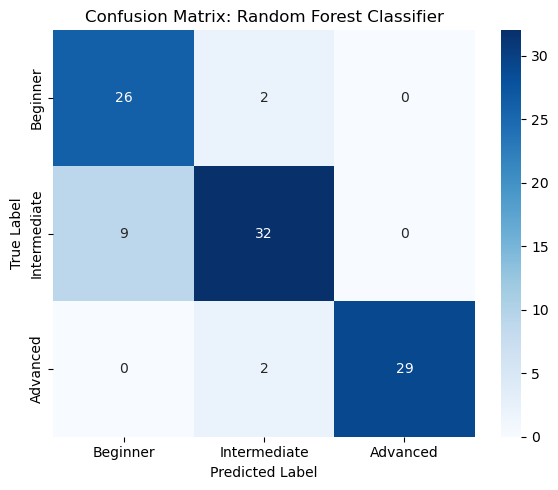

In [499]:
#predict the test set
y_pred = model.predict(X_test)

# make confusion matrix
cm = confusion_matrix(y_test, y_pred)

# class labels
labels = ['Beginner', 'Intermediate', 'Advanced']

# Plot
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix: Random Forest Classifier')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig('confusion_matrix_random_forest.png')  # Save to file
plt.show()

Beginner: Model nailed this one with 26 out of 28 predictions correct.

Intermediate: More mixed — 9 people were misclassified as Beginner.

Advanced: Pretty sharp; only 2 predicted incorrectly as Intermediate.

The color shading in the image helps you quickly spot where the volume of predictions is highest — darker = more predictions.


Explore why Intermediate users are being misclassified as Beginner — maybe the features used don’t differentiate well at that boundary.

In [510]:
#create a function to predict next reccomended evel 
def predict_difficulty(time_taken, guesses_taken, success):
    input_data = [[time_taken, guesses_taken, success]]
    predicted_level = model.predict(input_data)[0]
    
    # Map back to label
    difficulty_map_rev = {0: 'beginner', 1: 'intermediate', 2: 'hard'}  # updated based on your merged levels
    return difficulty_map_rev[predicted_level]


In [512]:
# Example at end of a round
time_taken = 37.5  # seconds
guesses_taken = 4
success = 1  # or 0

next_level = predict_difficulty(time_taken, guesses_taken, success)

print("Next word difficulty level should be:", next_level)

# Then you use this to filter your word list:
# next_word = random.choice([w for w in hindi_words if word_difficulty_map[w] == next_level])


Next word difficulty level should be: intermediate


C:\Users\parni\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [71]:
#main game window
root = tk.Tk()
root.title("ShabDub")
root.geometry("400x400")  # Width x Height

# create place a welcome label
welcome_label = tk.Label(root, text="Welcome to ShabDub-!", font=("Arial", 16))
welcome_label.pack(pady=20)

#Language selection dropdown
language_label = tk.Label(root, text="Select Language:")
language_label.pack()

languages = ["English", "Hindi", "Gujarati"]
language_var = tk.StringVar()
language_dropdown = ttk.Combobox(root, textvariable=language_var, values=languages, state="readonly")
language_dropdown.current(0)  # Default to English
language_dropdown.pack(pady=5)

# Difficulty selection dropdown
difficulty_label = tk.Label(root, text="Select Difficulty Level:")
difficulty_label.pack()

difficulties = ["Beginner", "Intermediate", "Hard", "Guru"]
difficulty_var = tk.StringVar()
difficulty_dropdown = ttk.Combobox(root, textvariable=difficulty_var, values=difficulties, state="readonly")
difficulty_dropdown.current(0)  # Default to Beginner
difficulty_dropdown.pack(pady=5)

# Define the function to start the game
def start_game():
    selected_language = language_var.get()
    selected_difficulty = difficulty_var.get()
    print(f"Game starting with Language: {selected_language}, Difficulty: {selected_difficulty}")

#Start Game Button
start_button = tk.Button(root, text="Start ShabDub", command=start_game)
start_button.pack(pady=20)

#Launch the UI loop
root.mainloop()

Game starting with Language: English, Difficulty: Beginner
Game starting with Language: English, Difficulty: Beginner


In [ ]:
import streamlit as st


# Helper to compare guess to answer and give feedback colors
def get_feedback_colors(guess, answer):
    feedback = ['gray'] * len(guess)
    answer_chars = list(answer)
    
    # First pass: green for correct letters in correct positions
    for i in range(len(guess)):
        if guess[i] == answer[i]:
            feedback[i] = 'green'
            answer_chars[i] = None  # Mark as used
    
    # Second pass: yellow for correct letters in wrong positions
    for i in range(len(guess)):
        if feedback[i] == 'gray' and guess[i] in answer_chars:
            feedback[i] = 'yellow'
            answer_chars[answer_chars.index(guess[i])] = None  # Mark as used

    return feedback

# Load word list (for now, we use a sample list)
word_list = ['apple', 'grape', 'mango', 'peach', 'lemon']
correct_word = random.choice(word_list)

# Store guesses using session state
if 'guesses' not in st.session_state:
    st.session_state.guesses = []

# UI header
st.title("🟩 Word Guess Game")
st.subheader("Try to guess the 5-letter word!")

# User input box
user_input = st.text_input("Enter your guess (5 letters):", max_chars=5)

# Button to submit guess
if st.button("Submit Guess") and len(user_input) == 5:
    st.session_state.guesses.append(user_input.lower())

# Show guess history with feedback
for guess in st.session_state.guesses:
    colors = get_feedback_colors(guess, correct_word)
    st.write("".join([f":{color}_square:" for color in colors]), f" → {guess}")

# Success message
if st.session_state.guesses and st.session_state.guesses[-1] == correct_word:
    st.success("🎉 You guessed it!")
